In [38]:
import json
import pandas as pd
import matplotlib.pyplot as plt

with open("../results/claude-3-7-sonnet-20250219--identify_crate_v1.json", "r") as f:
    data = json.load(f)

In [39]:
records = []
for entry in data:
    record = {
        "code_sample": entry["code_sample"],
        "granularity": entry["code_sample"].split("/")[-1],
        "crate_name_match": entry["scoring"]["crate_name_match"],
        "year_match": entry["scoring"]["year_match"],
        "cve_correct": len(entry["scoring"]["cve_inference"]["correct_predictions"]),
        "cve_missed": len(entry["scoring"]["cve_inference"]["missed_predictions"]),
        "cve_extra": len(entry["scoring"]["cve_inference"]["extra_predictions"]),
    }
    records.append(record)

df = pd.DataFrame(records)

In [40]:
df.head()

,code_sample,granularity,crate_name_match,year_match,cve_correct,cve_missed,cve_extra
0,vuln-0001/vuln-function,vuln-function,False,False,0,1,1
1,vuln-0001/vuln-file,vuln-file,False,False,0,1,1
2,vuln-0001/vuln-crate,vuln-crate,True,False,0,1,1
3,vuln-0002/vuln-crate,vuln-crate,True,False,0,1,1
4,vuln-0002/vuln-file,vuln-file,True,False,1,0,0


In [41]:
print("=== Overall Accuracy ===")

total = len(df)

crate_matches = df["crate_name_match"].sum()
year_matches = df["year_match"].sum()
cve_matches = df["cve_correct"].astype(bool).sum()  # at least 1 correct CVE

print(f"Crate name match: {crate_matches}/{total} ({crate_matches/total:.1%})")
print(f"Year match: {year_matches}/{total} ({year_matches/total:.1%})")
print(f"CVE match (at least 1 correct): {cve_matches}/{total} ({cve_matches/total:.1%})")

print("\n=== Breakdown by Granularity ===")
for granularity, group in df.groupby("granularity"):
    g_total = len(group)
    g_crate = group["crate_name_match"].sum()
    g_year = group["year_match"].sum()
    g_cve = group["cve_correct"].astype(bool).sum()
    print(f"\n{granularity}:")
    print(f"  Crate match: {g_crate}/{g_total} ({g_crate/g_total:.1%})")
    print(f"  Year match: {g_year}/{g_total} ({g_year/g_total:.1%})")
    print(f"  CVE match (≥1 correct): {g_cve}/{g_total} ({g_cve/g_total:.1%})")


=== Overall Accuracy ===
Crate name match: 10/15 (66.7%)
Year match: 3/15 (20.0%)
CVE match (at least 1 correct): 1/15 (6.7%)

=== Breakdown by Granularity ===

vuln-crate:
  Crate match: 5/5 (100.0%)
  Year match: 1/5 (20.0%)
  CVE match (≥1 correct): 0/5 (0.0%)

vuln-file:
  Crate match: 4/5 (80.0%)
  Year match: 1/5 (20.0%)
  CVE match (≥1 correct): 1/5 (20.0%)

vuln-function:
  Crate match: 1/5 (20.0%)
  Year match: 1/5 (20.0%)
  CVE match (≥1 correct): 0/5 (0.0%)


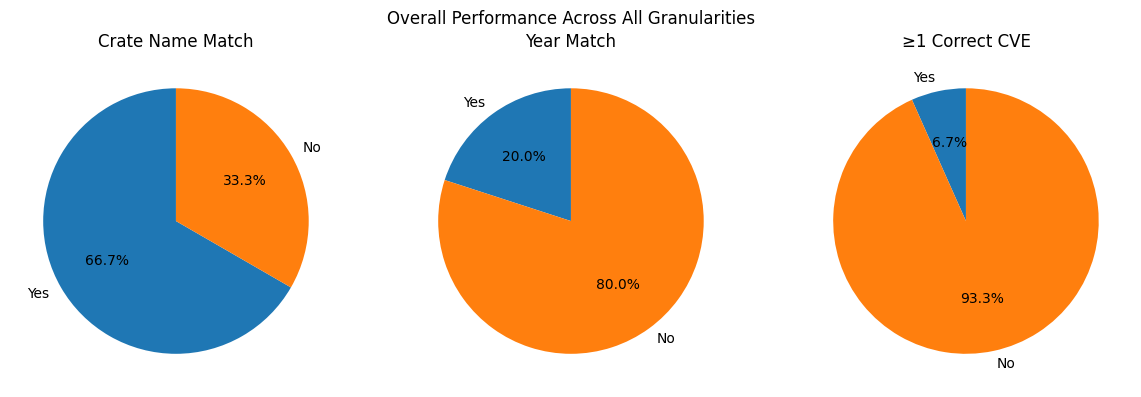

In [42]:
import matplotlib.pyplot as plt

metrics = {
    "Crate Name Match": df["crate_name_match"],
    "Year Match": df["year_match"],
    "≥1 Correct CVE": df["cve_correct"].astype(bool)
}

plt.figure(figsize=(12, 4))

for idx, (title, series) in enumerate(metrics.items(), 1):
    plt.subplot(1, 3, idx)
    counts = series.value_counts(normalize=True)
    # Ensure 'Yes' (True) comes first
    counts = counts.reindex([True, False], fill_value=0)
    counts.plot.pie(
        autopct="%1.1f%%",
        startangle=90,
        labels=["Yes", "No"],
        ylabel="",
        title=title
    )

plt.suptitle("Overall Performance Across All Granularities")
plt.tight_layout()
plt.show()


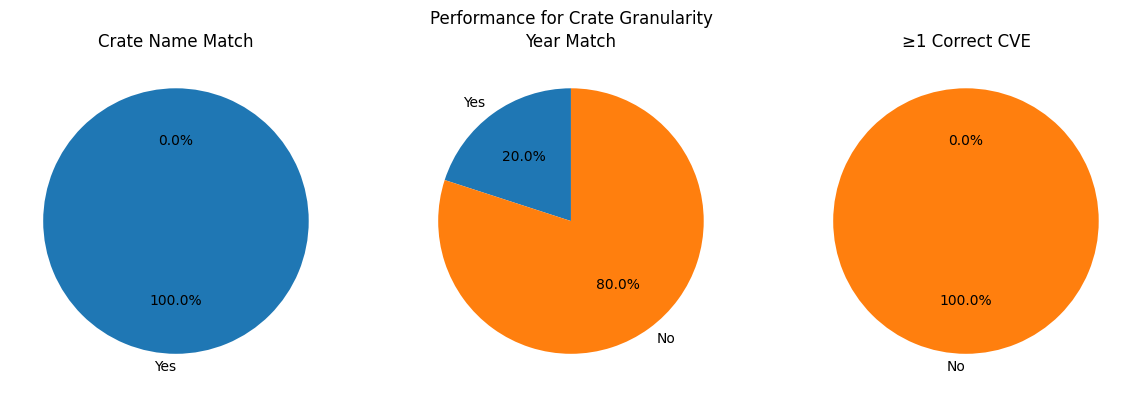

In [43]:
crate_df = df[df["granularity"] == "vuln-crate"]

metrics = {
    "Crate Name Match": crate_df["crate_name_match"],
    "Year Match": crate_df["year_match"],
    "≥1 Correct CVE": crate_df["cve_correct"].astype(bool)
}

plt.figure(figsize=(12, 4))

for idx, (title, series) in enumerate(metrics.items(), 1):
    plt.subplot(1, 3, idx)
    counts = series.value_counts(normalize=True)
    # Ensure 'Yes' (True) comes first
    counts = counts.reindex([True, False], fill_value=0)
    counts.plot.pie(
        autopct="%1.1f%%",
        startangle=90,
        labels=["Yes", "No"],
        ylabel="",
        title=title
    )

plt.suptitle("Performance for Crate Granularity")
plt.tight_layout()
plt.show()

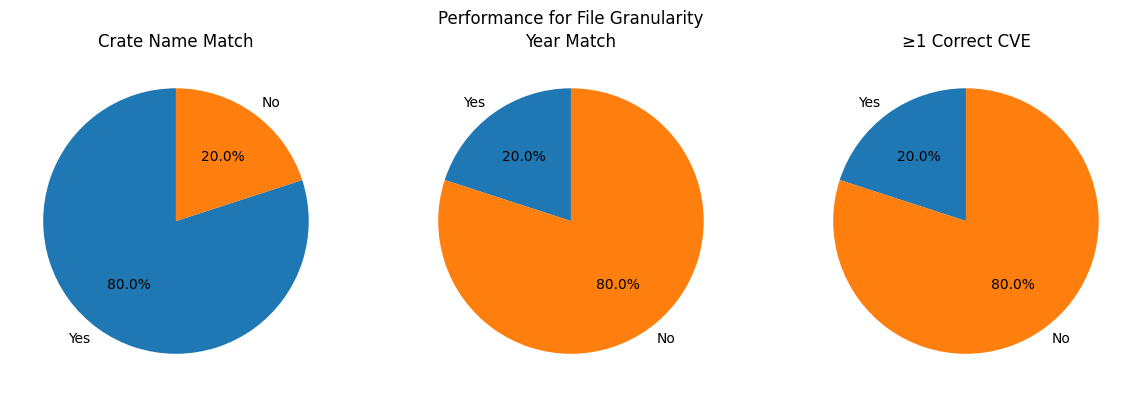

In [44]:
file_df = df[df["granularity"] == "vuln-file"]

metrics = {
    "Crate Name Match": file_df["crate_name_match"],
    "Year Match": file_df["year_match"],
    "≥1 Correct CVE": file_df["cve_correct"].astype(bool)
}

plt.figure(figsize=(12, 4))

for idx, (title, series) in enumerate(metrics.items(), 1):
    plt.subplot(1, 3, idx)
    counts = series.value_counts(normalize=True)
    # Ensure 'Yes' (True) comes first
    counts = counts.reindex([True, False], fill_value=0)
    counts.plot.pie(
        autopct="%1.1f%%",
        startangle=90,
        labels=["Yes", "No"],
        ylabel="",
        title=title
    )

plt.suptitle("Performance for File Granularity")
plt.tight_layout()
plt.show()


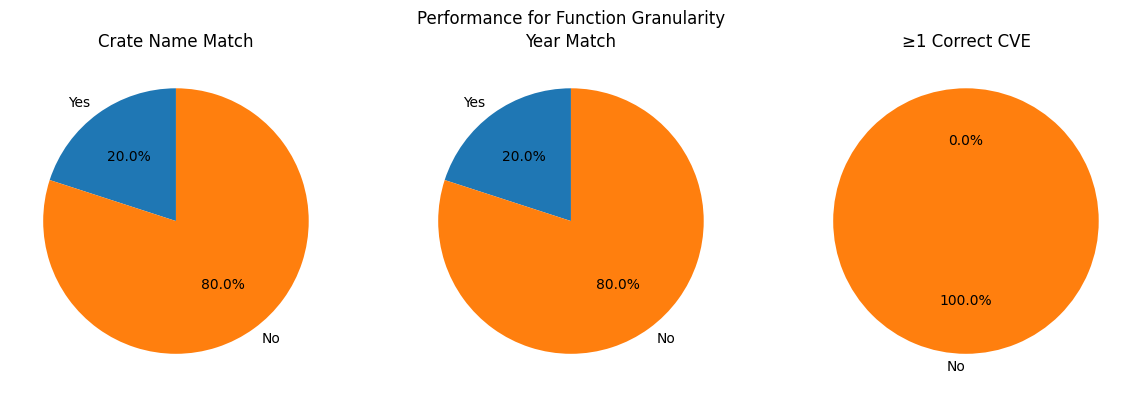

In [45]:
function_df = df[df["granularity"] == "vuln-function"]

metrics = {
    "Crate Name Match": function_df["crate_name_match"],
    "Year Match": function_df["year_match"],
    "≥1 Correct CVE": function_df["cve_correct"].astype(bool)
}

plt.figure(figsize=(12, 4))

for idx, (title, series) in enumerate(metrics.items(), 1):
    plt.subplot(1, 3, idx)
    counts = series.value_counts(normalize=True)
    # Ensure 'Yes' (True) comes first
    counts = counts.reindex([True, False], fill_value=0)
    counts.plot.pie(
        autopct="%1.1f%%",
        startangle=90,
        labels=["Yes", "No"],
        ylabel="",
        title=title
    )

plt.suptitle("Performance for Function Granularity")
plt.tight_layout()
plt.show()